# MRS Bulletin Figures
> Georgios Varnavides, Willem de Kleijne, Stephanie Ribet

## Gamma Function Tableau

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import quantem as em

In [2]:
# parameters
n = 192
k_max = 2 # inverse Angstroms
k_probe = 1 # inverse Angstroms
wavelength = 0.019687 # 300kV
sampling = 1 / k_max / 2 # Angstroms
reciprocal_sampling = 2 * k_max / n # inverse Angstroms
C10 = 2e2

In [3]:
# we build probe in Fourier space, using a soft aperture

kx = ky = np.fft.fftfreq(n,sampling)
k2 = kx[:,None]**2 + ky[None,:]**2
k  = np.sqrt(k2)
phi = np.arctan2(ky[None,:],kx[:,None])

unrolled_chi = np.pi*wavelength*C10*k2
def soft_aperture(k,k_probe=k_probe,reciprocal_sampling=reciprocal_sampling):
    """ """
    return np.sqrt(
        np.clip(
            (k_probe - k)/reciprocal_sampling + 0.5,
            0,
            1,
        ),
    )

def return_complex_probe(
    k,
    C10,
    wavelength=wavelength,
):
    """ """
    probe_array_fourier_0 = soft_aperture(k)
    probe_array_fourier_0 /= np.sqrt(np.sum(np.abs(probe_array_fourier_0)**2))
    return probe_array_fourier_0 * np.exp(-1j*np.pi*wavelength*C10*k**2)

aperture_fourier = soft_aperture(k)
probe_array_fourier = return_complex_probe(k,C10)

(<Figure size 400x800 with 2 Axes>, array([<Axes: >, <Axes: >], dtype=object))

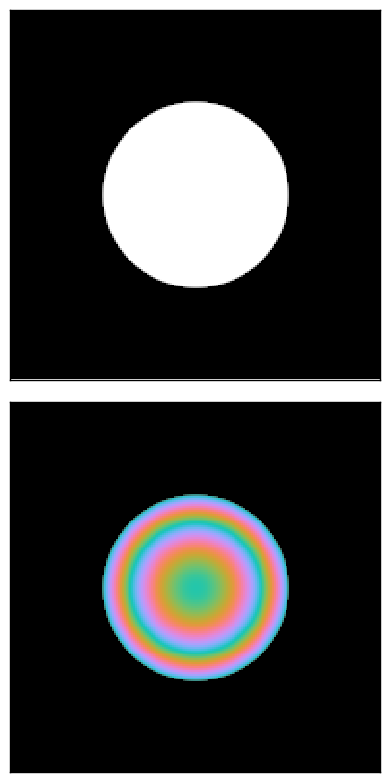

In [17]:
em.visualization.show_2d(
    [
        [np.fft.fftshift(aperture_fourier)],
        [np.fft.fftshift(probe_array_fourier)]
    ]
)

In [4]:
def return_aperture_overlap_factor(
    unrolled_chi,
    k_qm,
    k_qp
):
    """ """
    aperture_minus = soft_aperture(k_qm)
    aperture_plus = soft_aperture(k_qp)
    
    beta = np.exp(-1j*unrolled_chi)*aperture_minus - np.exp(1j*unrolled_chi)*aperture_plus
    beta_abs = np.abs(beta)
    beta_abs[beta_abs==0] = np.inf
    aperture_overlap_factor = beta.conj() / beta_abs
    return aperture_overlap_factor

def return_full_gamma_factor(
    complex_probe_factor,
    k_qm,
    k_qp,
    C10,
):
    """ """
    shifted_probe_minus = return_complex_probe(k_qm,C10)
    shifted_probe_plus = return_complex_probe(k_qp,C10)
    gamma = shifted_probe_minus*complex_probe_factor.conjugate() - shifted_probe_plus.conjugate()*complex_probe_factor
    return gamma

def return_full_gamma_factor_k(
    complex_probe,
    k_qm,
    k_qp,
    C10,
):
    """ """
    shifted_probe_minus = return_complex_probe(k_qm,C10)
    shifted_probe_plus = return_complex_probe(k_qp,C10)
    gamma = shifted_probe_minus*complex_probe.conjugate() - shifted_probe_plus.conjugate()*complex_probe
    return gamma

In [6]:
def classic_gamma_factor_at_k_index(
    kx_index,
    ky_index
):
    
    kx_qx = kx - kx[kx_index]
    ky_qy = ky - ky[ky_index]
    k_qm = np.sqrt(kx_qx[:,None]**2 + ky_qy[None,:]**2)
    
    kx_qx = kx + kx[kx_index]
    ky_qy = ky + ky[ky_index]
    k_qp = np.sqrt(kx_qx[:,None]**2 + ky_qy[None,:]**2)
    
    full_gamma_factor_k = return_full_gamma_factor_k(
        probe_array_fourier,
        k_qm,
        k_qp,
        C10
    )

    return full_gamma_factor_k

In [7]:
step = 12

gamma_00 = classic_gamma_factor_at_k_index(0,0)
gamma_10 = classic_gamma_factor_at_k_index(step,0)
gamma_01 = classic_gamma_factor_at_k_index(0,step)
gamma_11 = classic_gamma_factor_at_k_index(step,step)
gamma_20 = classic_gamma_factor_at_k_index(3*step,0)
gamma_02 = classic_gamma_factor_at_k_index(0,3*step)
gamma_21 = classic_gamma_factor_at_k_index(3*step,step)
gamma_12 = classic_gamma_factor_at_k_index(step,3*step)
gamma_22 = classic_gamma_factor_at_k_index(3*step,3*step)

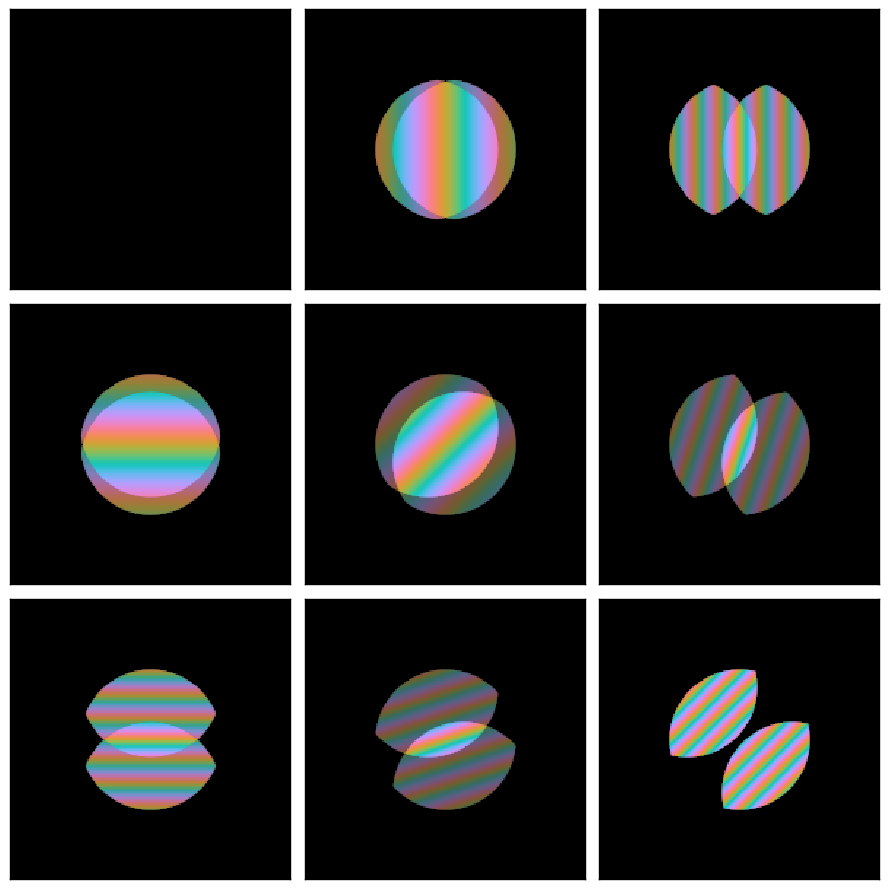

In [8]:
fig_gamma_k, axs_gamma_k =em.visualization.show_2d(
    [
        [
            np.fft.fftshift(gamma_00),
            np.fft.fftshift(gamma_01),
            np.fft.fftshift(gamma_02),
        ],
        [
            np.fft.fftshift(gamma_10),
            np.fft.fftshift(gamma_11),
            np.fft.fftshift(gamma_12),
        ],
        [
            np.fft.fftshift(gamma_20),
            np.fft.fftshift(gamma_21),
            np.fft.fftshift(gamma_22),
        ]
    ],
    axsize=(3,3)
)

In [9]:
def gamma_factor_at_q_index(
    kx_index,
    ky_index
):
    
    kx_qx = kx - kx[kx_index]
    ky_qy = ky - ky[ky_index]
    k_qm = np.sqrt(kx_qx[:,None]**2 + ky_qy[None,:]**2)
    
    kx_qx = kx + kx[kx_index]
    ky_qy = ky + ky[ky_index]
    k_qp = np.sqrt(kx_qx[:,None]**2 + ky_qy[None,:]**2)
    
    complex_probe_factor = probe_array_fourier[kx_index,ky_index]
    full_gamma_factor = return_full_gamma_factor(
        complex_probe_factor,
        k_qm,
        k_qp,
        C10
    )

    return full_gamma_factor

In [10]:
step = 8

q_gamma_00 = gamma_factor_at_q_index(0,0)
q_gamma_10 = gamma_factor_at_q_index(step,0)
q_gamma_01 = gamma_factor_at_q_index(0,step)
q_gamma_11 = gamma_factor_at_q_index(step,step)
q_gamma_20 = gamma_factor_at_q_index(3*step,0)
q_gamma_02 = gamma_factor_at_q_index(0,3*step)
q_gamma_21 = gamma_factor_at_q_index(3*step,step)
q_gamma_12 = gamma_factor_at_q_index(step,3*step)
q_gamma_22 = gamma_factor_at_q_index(3*step,3*step)

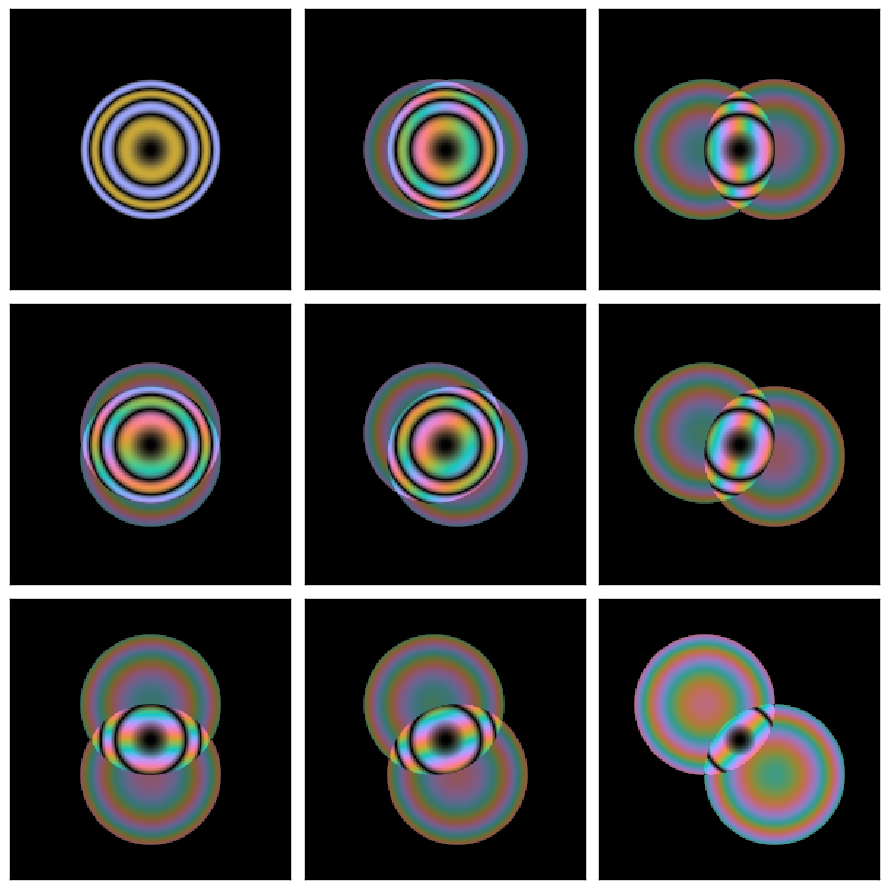

In [11]:
fig_gamma, axs_gamma = em.visualization.show_2d(
    [
        [
            np.fft.fftshift(q_gamma_00),
            np.fft.fftshift(q_gamma_01),
            np.fft.fftshift(q_gamma_02),
        ],
        [
            np.fft.fftshift(q_gamma_10),
            np.fft.fftshift(q_gamma_11),
            np.fft.fftshift(q_gamma_12),
        ],
        [
            np.fft.fftshift(q_gamma_20),
            np.fft.fftshift(q_gamma_21),
            np.fft.fftshift(q_gamma_22),
        ]
    ],
    axsize=(3,3)
);

In [12]:
def beta_factor_at_q_index(
    kx_index,
    ky_index
):
    
    kx_qx = kx - kx[kx_index]
    ky_qy = ky - ky[ky_index]
    k_qm = np.sqrt(kx_qx[:,None]**2 + ky_qy[None,:]**2)
    
    kx_qx = kx + kx[kx_index]
    ky_qy = ky + ky[ky_index]
    k_qp = np.sqrt(kx_qx[:,None]**2 + ky_qy[None,:]**2)
    
    aperture_overlap_factor = return_aperture_overlap_factor(
        unrolled_chi,
        k_qm,
        k_qp
    )

    return aperture_overlap_factor

In [13]:
step = 8

q_beta_00 = beta_factor_at_q_index(0,0)
q_beta_10 = beta_factor_at_q_index(step,0)
q_beta_01 = beta_factor_at_q_index(0,step)
q_beta_11 = beta_factor_at_q_index(step,step)
q_beta_20 = beta_factor_at_q_index(3*step,0)
q_beta_02 = beta_factor_at_q_index(0,3*step)
q_beta_21 = beta_factor_at_q_index(3*step,step)
q_beta_12 = beta_factor_at_q_index(step,3*step)
q_beta_22 = beta_factor_at_q_index(3*step,3*step)

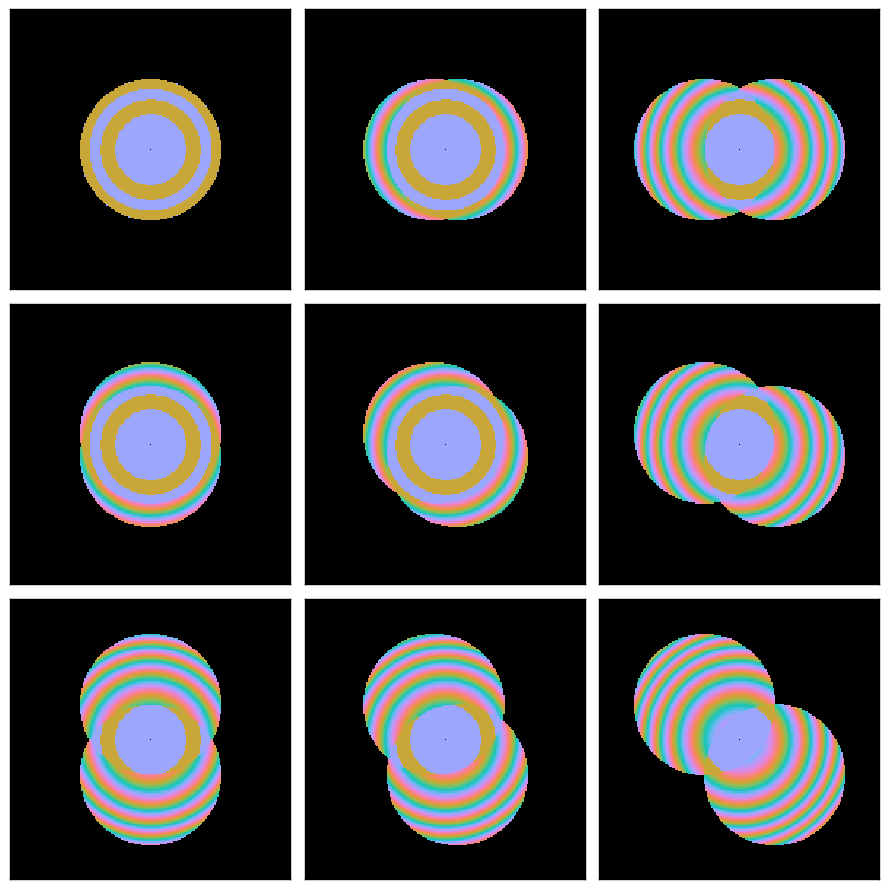

In [14]:
fig_beta, axs_beta = em.visualization.show_2d(
    [
        [
            np.fft.fftshift(q_beta_00),
            np.fft.fftshift(q_beta_01),
            np.fft.fftshift(q_beta_02),
        ],
        [
            np.fft.fftshift(q_beta_10),
            np.fft.fftshift(q_beta_11),
            np.fft.fftshift(q_beta_12),
        ],
        [
            np.fft.fftshift(q_beta_20),
            np.fft.fftshift(q_beta_21),
            np.fft.fftshift(q_beta_22),
        ]
    ],
    axsize=(3,3)
)

In [15]:
fig_beta.savefig("beta_tableau.pdf",bbox_inches='tight')
fig_gamma.savefig("gamma_tableau.pdf",bbox_inches='tight')
fig_gamma_k.savefig("gamma_k_tableau.pdf",bbox_inches='tight')